# Прогнозирование вероятности дефолта заемщика (Credit Scoring)
## Описание проекта
Решение классической задачи банковского сектора - кредитного скоринга. На основе данных о заемщиках необходимо построить модель, которая максимально точно предскажет вероятность невозврата кредита заемщиком. 
## Цель исследования
Разработать и сравнить несколько моделей машинного обучения для автоматизации процесса оценки кредитных рисков. Провести полный цикл разработки, включающий в себя разведочный анализ данных, обработка базы данных, обучений моделей, сравнение и анализ результатов.
## Описание данных 
Датасет содержит информацию о заемщиках и параметрах кредита. Данные представляют собой числовые значения или объекты. Некоторые данные заполнялись лично заемщиком, некоторые - информация из банка:
* person_age - возраст;                      
* person_income - доход;
* person_home_ownership - статус владения жильем (аренда, собственность итд);  
* person_emp_length - трудовой стаж;
* loan_intent - цель кредита; 
* loan_grade - кредитный рейтинг;                      
* loan_amnt - сумма займа;                        
* loan_int_rate - процентная ставка по кредиту;               
* **loan_status - статус кредита (выплачен/дефолт);**                     
* loan_percent_income - доля кредита от дохода;              
* cb_person_default_on_file - информация о невозврате кредита в прошлом;      
* cb_person_cred_hist_length - длительность кредитной истории.
## Основные этапы работы
* Exploratory Data Analysis (EDA): Исследование распределений, поиск корреляций и визуализация признаков дефолтных заемщиков.
* Data Cleaning: Обработка пропусков и удаление аномальных значений (выбросов) в возрасте и стаже работы.
* Feature Engineering: Кодирование категориальных признаков и масштабирование числовых данных.
* Model Comparison: Обучение моделей и оценка их качества с помощью матрицы ошибок и метрик Accuracy, Recall и F1-score.
## Стек
* Анализ и визуализация - Pandas, Numpy, Matplotlib, Seaborn
* Предобработка и обучение - Scikit-learn

# 1. EDA

In [214]:
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from catboost import CatBoostClassifier
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score
from sklearn.preprocessing import OneHotEncoder

In [84]:
pink_palette = ["#FF1493", "#FF69B4", "#FF85A2", "#FF9AA2", "#FFB7B2", "#FFC0CB", "#FFD1DC", "#FFE4E1", "#FFF0F5", "#FFF5EE"]

## Первичная диагностика базы данных
Датасет состоит из 32581 объекта c 12 признаками, числовыми и категориальными. Сразу видно, что в person_emp_length и loan_int_rate присутствуют пропуски.


In [7]:
data = pd.read_csv('credit_risk_dataset.csv')
display(data.head(6))
data.info()
data.describe()
data.describe(include='object')

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4
5,21,9900,OWN,2.0,VENTURE,A,2500,7.14,1,0.25,N,2


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3.0+ MB


,person_home_ownership,loan_intent,loan_grade,cb_person_default_on_file
count,32581,32581,32581,32581
unique,4,6,7,2
top,RENT,EDUCATION,A,N
freq,16446,6453,10777,26836


In [8]:
data.isnull().sum()

person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length              895
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 3116
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64

> Подтверждение информации о пропусках. <br>
> Cтаж работы и процентная ставка имеют пустые поля. <br> 
> Предварительная идея заполнять пропуски процентной ставки медианой. <br>
> Интересный факт - стаж работы заполняется заемщиком лично, пропуски могут говорить о сокрытии от банка информации о отсутствии работы на данный момент. Идея - заполнить пропуски медианой, но добавить флаг об отсутствии информации в поле.<br>

In [10]:
data.nunique()

person_age                      58
person_income                 4295
person_home_ownership            4
person_emp_length               36
loan_intent                      6
loan_grade                       7
loan_amnt                      753
loan_int_rate                  348
loan_status                      2
loan_percent_income             77
cb_person_default_on_file        2
cb_person_cred_hist_length      29
dtype: int64

> В loan_status два варианта значений - аномалий нет <br>
> Нет столбцов с одинаковым значением по всем объектам <br>
> Нет столбцов с большим количеством тектовых значений

In [12]:
data.duplicated().sum()

165

## Анализ целевой переменной


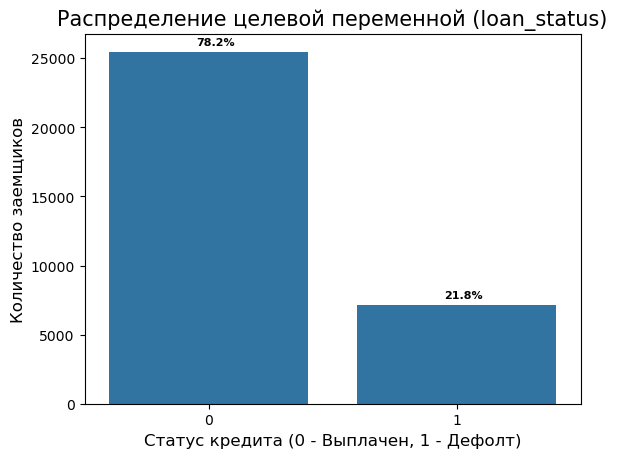

Точное количество по классам:
loan_status
0    25473
1     7108
Name: count, dtype: int64


In [247]:
ax = sns.countplot(x='loan_status', data=data)
total = len(data)
for p in ax.patches:
    percentage = f'{100 * p.get_height() / total:.1f}%'
    x = p.get_x() + p.get_width() / 2 - 0.05
    y = p.get_height() + 500
    ax.annotate(percentage, (x, y), fontsize=8, fontweight='bold')
plt.title('Распределение целевой переменной (loan_status)', fontsize=15)
plt.xlabel('Статус кредита (0 - Выплачен, 1 - Дефолт)', fontsize=12)
plt.ylabel('Количество заемщиков', fontsize=12)
plt.show()
print("Точное количество по классам:")
print(data['loan_status'].value_counts())

> Вывод по анализу целевой переменной:
> * В датасете наблюдается явный дисбаланс классов: около 78% заемщиков успешно выплатили кредит, и 22% допустили дефолт.
> * Метрика Accuracy некорректна, модель может просто научиться всегда отвечать "0" и получит точность 78%, но при этом она не найдет ни одного проблемного клиента. 
> * Решение: Для оценки будущей модели будут использоваться другие метрики;

## Поиск выбросов и аномалий, исправление
Ранее было отмечено что максимальные значения для возраста и стажа работы более 100 лет, поиск аномалий будет начат именно с этих признаков

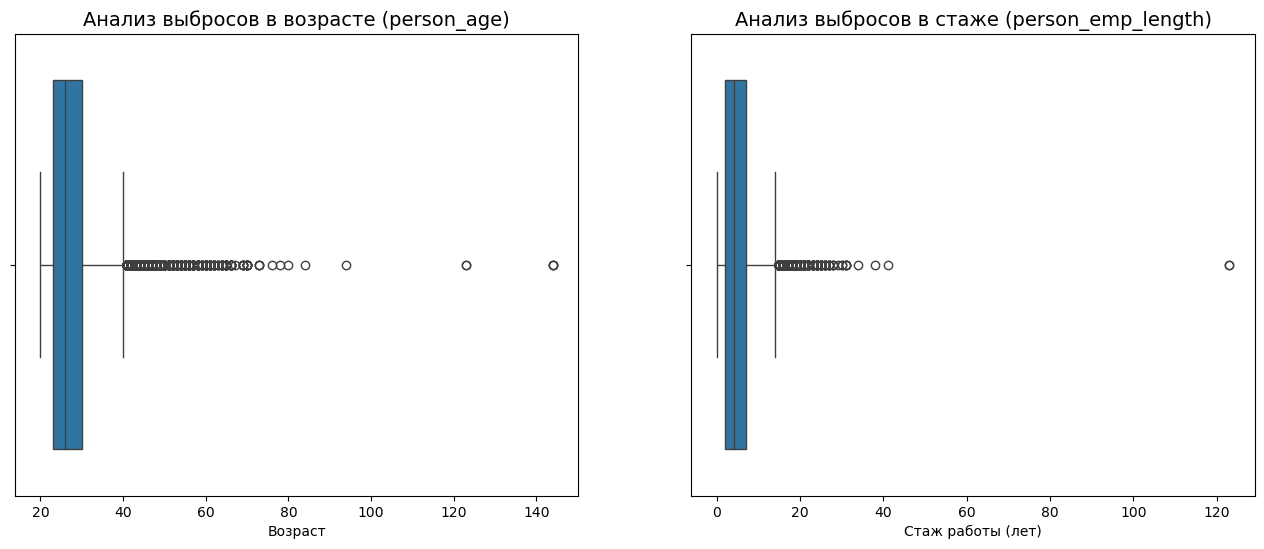

In [265]:
plt.figure(figsize=(16, 6))
plt.subplot(1, 2, 1)
sns.boxplot(x=data['person_age'])
plt.title('Анализ выбросов в возрасте (person_age)', fontsize=14)
plt.xlabel('Возраст')

# 2. График для Стажа работы
plt.subplot(1, 2, 2)
sns.boxplot(x=data['person_emp_length'])
plt.title('Анализ выбросов в стаже (person_emp_length)', fontsize=14)
plt.xlabel('Стаж работы (лет)')

plt.show()

> Найденные аномалии:
> * Обнаружены заемщики старше 100 лет (максимум 144 года), что противоречит Книге рекордов Гинесса (максимальный возраст человека 122 года). Но базе данных присутствуют возрастные заемщики, чтобы не потерять важную информацию будут удалены все, чей возраст больше 100 лет.
> * Обнаружены значения стажа более 100 лет (максимум 123 года), что также является ошибкой ввода, такой выброс единичный. Будут удалены все, чей стаж работы больше 60 лет.


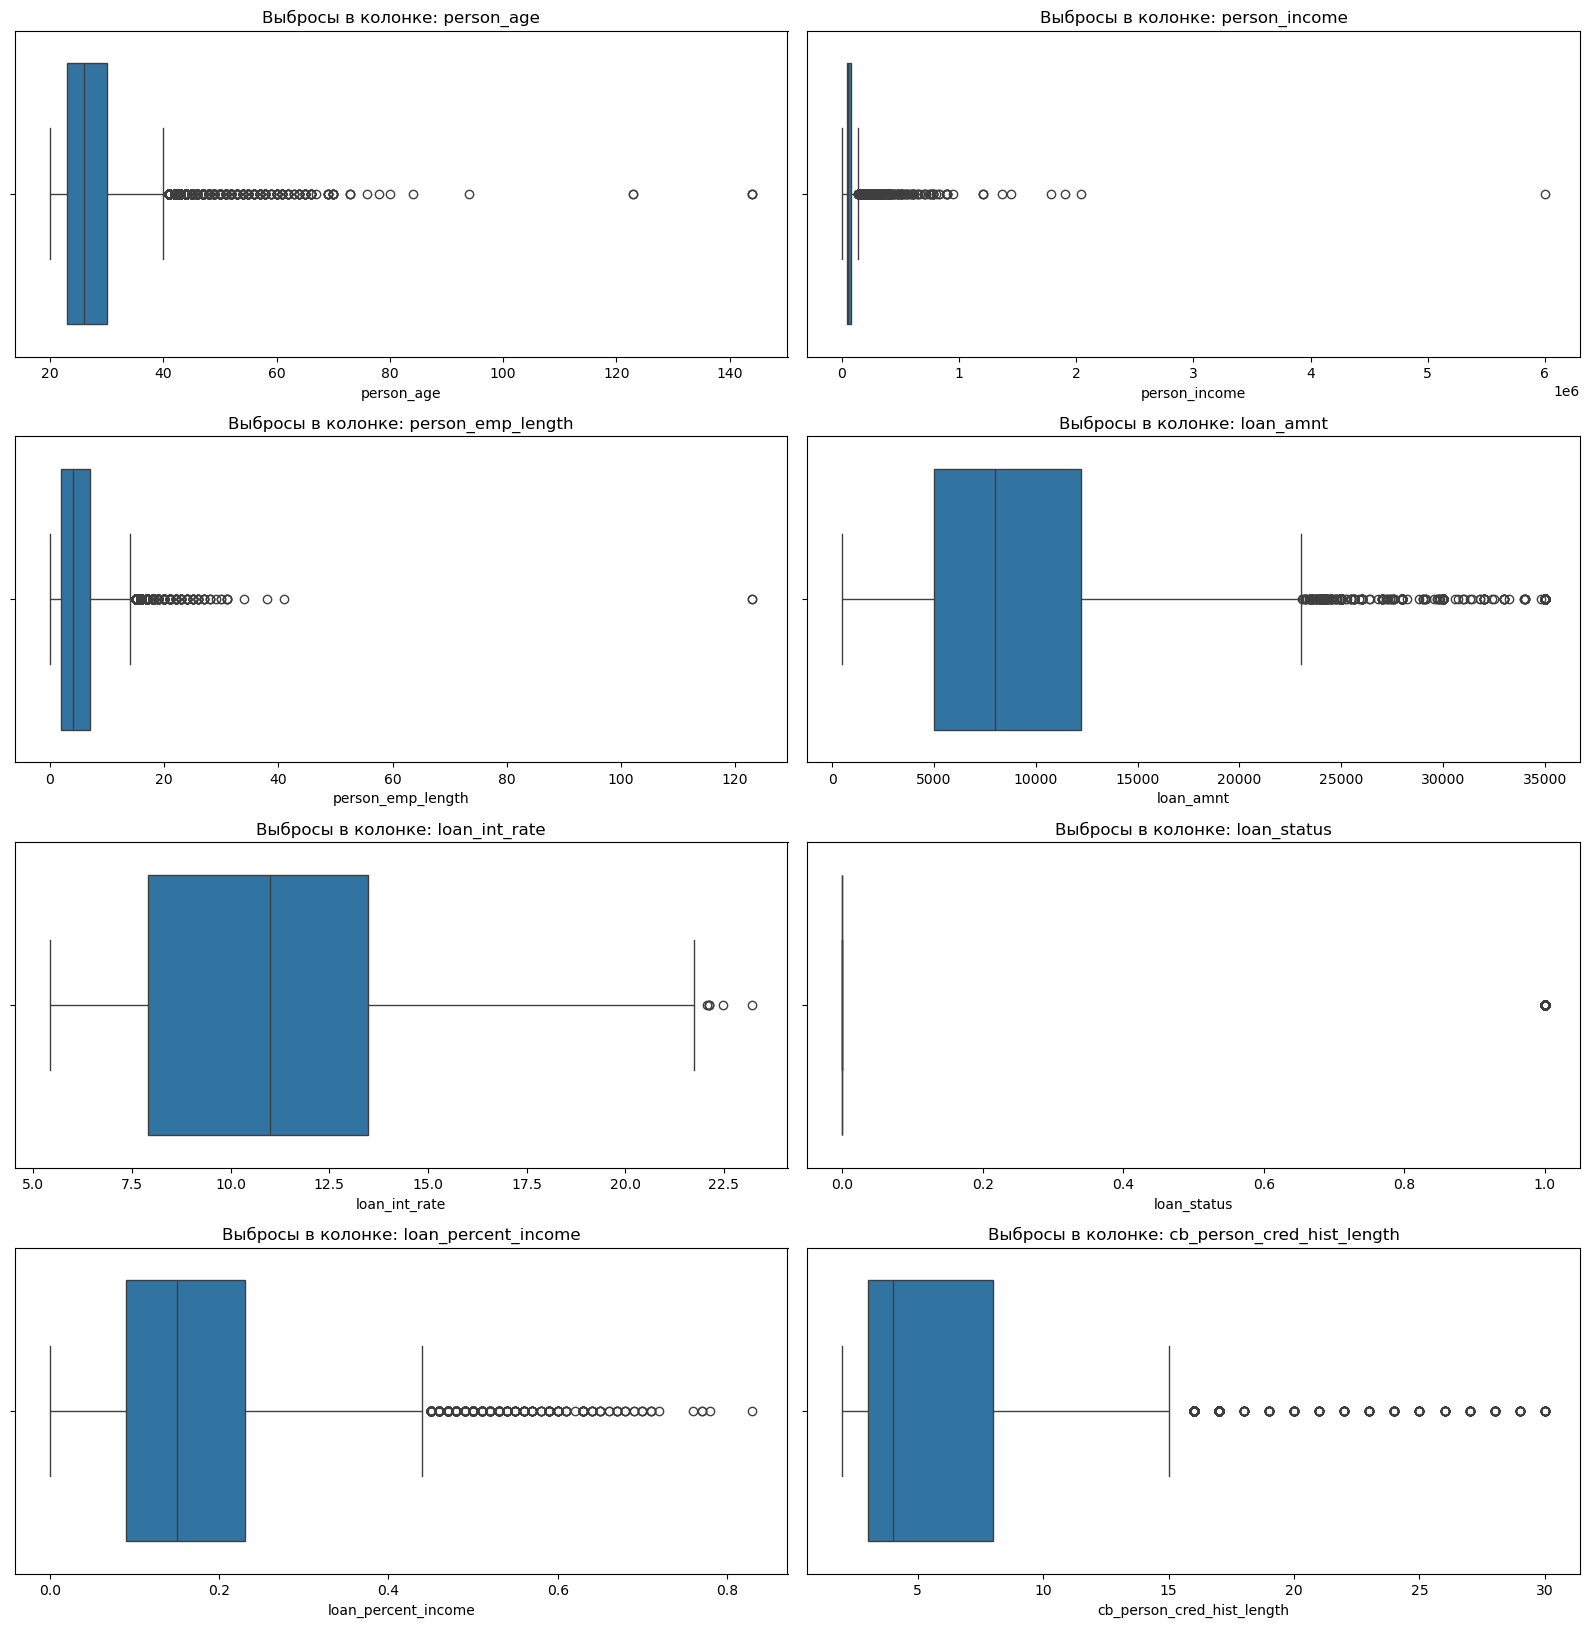

In [267]:
num_columns = data.select_dtypes(include=['float64', 'int64']).columns
plt.figure(figsize=(16, 20))
for i, column in enumerate(num_columns):
    plt.subplot(len(num_columns) // 2 + 1, 2, i + 1)
    sns.boxplot(x=data[column])
    plt.title(f'Выбросы в колонке: {column}', fontsize=12)
    plt.tight_layout()
plt.show()

> Выбросы из "усов" имеют большую ценность и их следует оставить. 

Процентная ставка заполняется медианой. <br>
Со стажем ситуация обстоит интереснее - довольно много пропусков, с учетом того что в остальных данных пропусков нет. Следовательно заполним медианой НО добавим флажок отсутствия данных - и далее можно будет оценить влияние на дефолт этого признака

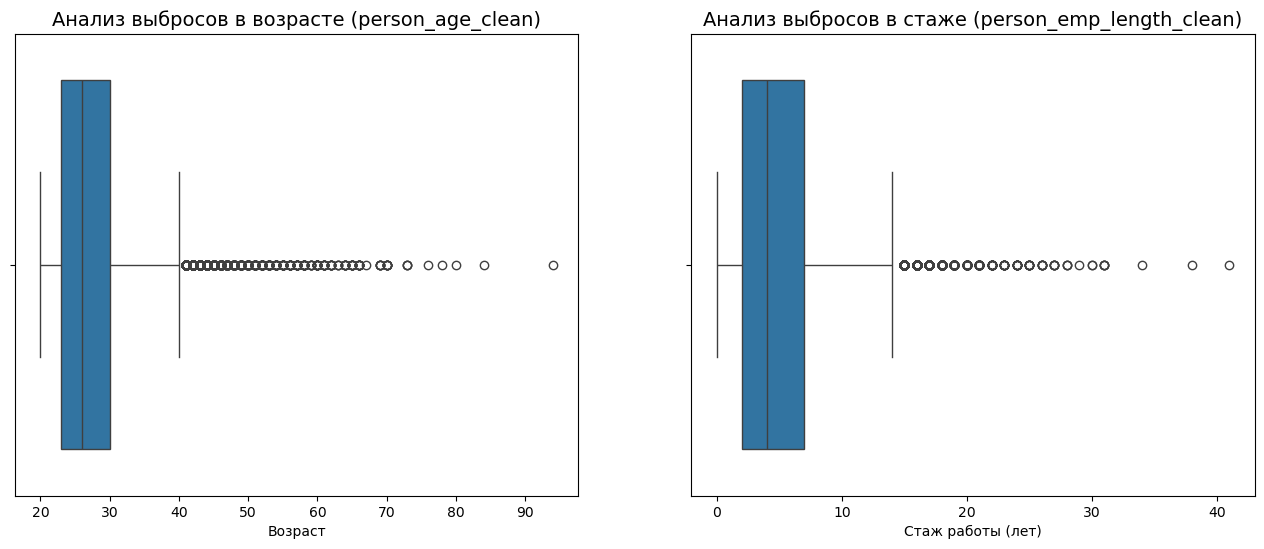

person_age                    0
person_income                 0
person_home_ownership         0
person_emp_length             0
loan_intent                   0
loan_grade                    0
loan_amnt                     0
loan_int_rate                 0
loan_status                   0
loan_percent_income           0
cb_person_default_on_file     0
cb_person_cred_hist_length    0
emp_length_is_missing         0
dtype: int64


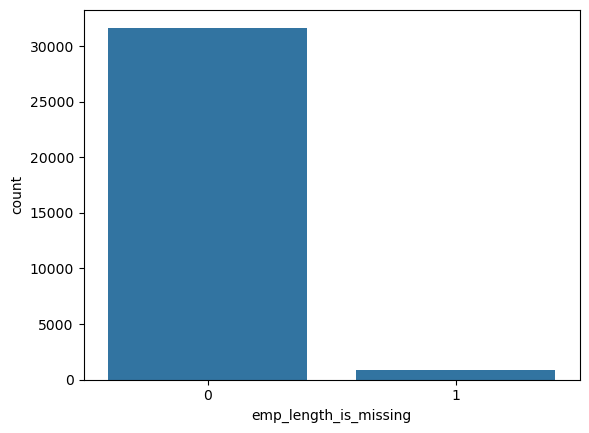

In [261]:
data_clean = data.copy()
data_clean = data_clean[data_clean['person_age']<100]
data_clean = data_clean[(data_clean['person_emp_length']<60) | (data_clean['person_emp_length'].isnull())]
plt.figure(figsize=(16, 6))
plt.subplot(1, 2, 1)
sns.boxplot(x=data_clean['person_age'])
plt.title('Анализ выбросов в возрасте (person_age_clean)', fontsize=14)
plt.xlabel('Возраст')
plt.subplot(1, 2, 2)
sns.boxplot(x=data_clean['person_emp_length'])
plt.title('Анализ выбросов в стаже (person_emp_length_clean)', fontsize=14)
plt.xlabel('Стаж работы (лет)')
plt.show()
data_clean['loan_int_rate'] = data_clean['loan_int_rate'].fillna(data_clean['loan_int_rate'].median())
data_clean['emp_length_is_missing'] = data_clean['person_emp_length'].isnull().astype(int)
data_clean['person_emp_length'] = data_clean['person_emp_length'].fillna(data_clean['person_emp_length'].median())
print(data_clean.isnull().sum())
ax = sns.countplot(x='emp_length_is_missing', data=data_clean)

## Поиск корреляций между признаками

In [131]:
data_clean.corr(numeric_only=True)

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length,emp_length_is_missing
person_age,1.000000,0.140497,0.170688,0.051751,0.011288,-0.020687,-0.041587,0.878094,-0.011743
person_income,0.140497,1.000000,0.155439,0.317497,-0.001051,-0.168485,-0.294558,0.123049,-0.069269
person_emp_length,0.170688,0.155439,1.000000,0.111820,-0.052830,-0.085613,-0.058515,0.147713,-0.032112
loan_amnt,0.051751,0.317497,0.111820,1.000000,0.139473,0.105240,0.572420,0.042240,-0.067724
loan_int_rate,0.011288,-0.001051,-0.052830,0.139473,1.000000,0.319320,0.114420,0.015724,-0.049136
loan_status,-0.020687,-0.168485,-0.085613,0.105240,0.319320,1.000000,0.379250,-0.015472,0.039437
loan_percent_income,-0.041587,-0.294558,-0.058515,0.572420,0.114420,0.379250,1.000000,-0.031447,0.032967
cb_person_cred_hist_length,0.878094,0.123049,0.147713,0.042240,0.015724,-0.015472,-0.031447,1.000000,-0.007490
emp_length_is_missing,-0.011743,-0.069269,-0.032112,-0.067724,-0.049136,0.039437,0.032967,-0.007490,1.000000


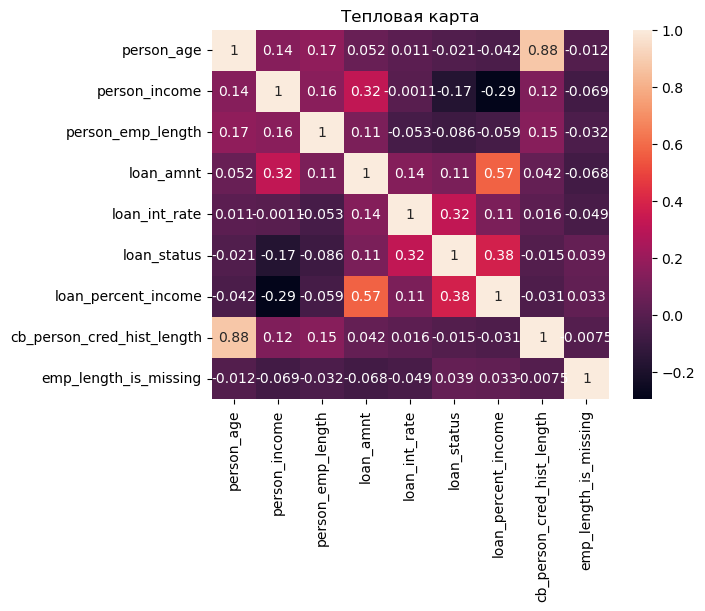

In [255]:
sns.heatmap(data_clean.corr(numeric_only=True), annot=True)
plt.title('Тепловая карта')
plt.show()

Первичная оценка корреляций числовых признаков:
> * Положительная корреляция - рост риска;
> * Наибольшее значение корреляции между таргетом и долей кредита к доходу (loan_percent_income), а также процентной ставкой (loan int rate);
> * Видна сильная зависимость между возрастом заемщика и длиной кредитной истории;
> * Для добавленого флага о пропусках в трудовом стаже значение корреляции с таргетом не очень большое, но оно положительное - что косвенно подтверждает тезис (помимо прочего, пропусков было не очень много и действительно большого значения там быть не может)

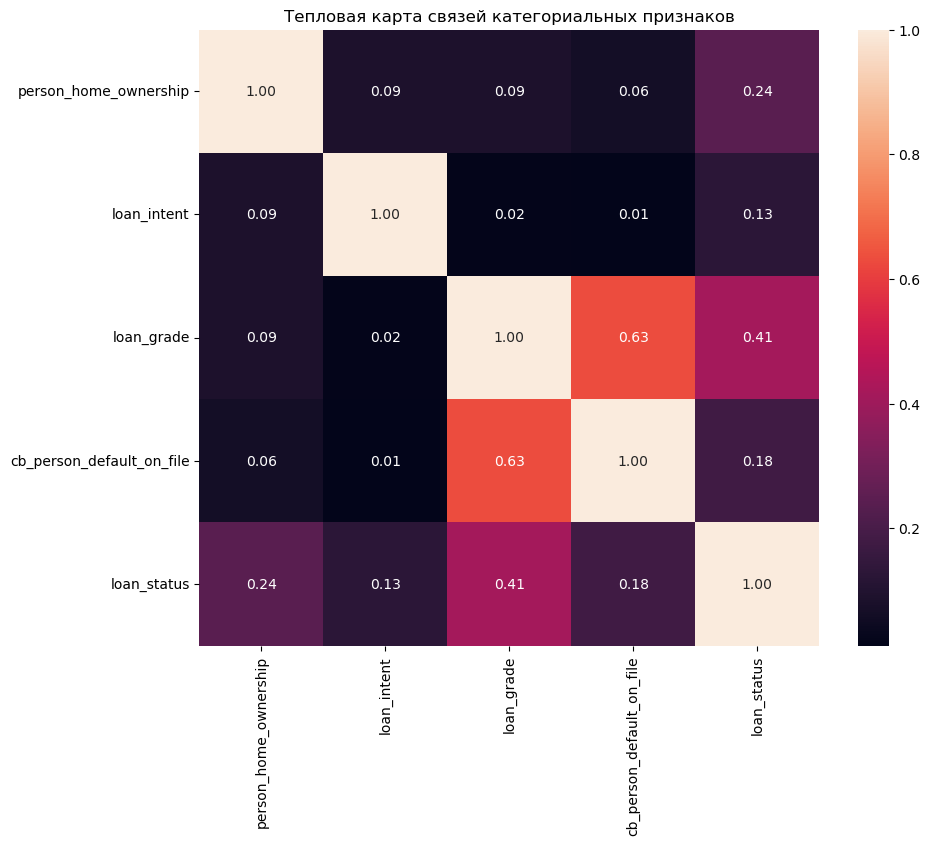

In [253]:
def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    phi2corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))
    rcorr = r - ((r-1)**2)/(n-1)
    kcorr = k - ((k-1)**2)/(n-1)
    return np.sqrt(phi2corr / min((kcorr-1), (rcorr-1)))
cat_cols = data_clean.select_dtypes(include=['object']).columns.tolist()
cat_cols.append('loan_status')
corr_cat_matrix = pd.DataFrame(index=cat_cols, columns=cat_cols)
for col1 in cat_cols:
    for col2 in cat_cols:
        corr_cat_matrix.loc[col1, col2] = cramers_v(data_clean[col1], data_clean[col2])
corr_cat_matrix = corr_cat_matrix.astype(float)
plt.figure(figsize=(10, 8))
sns.heatmap(corr_cat_matrix, annot=True, fmt='.2f')
plt.title('Тепловая карта связей категориальных признаков')
plt.show()

Первичная оценка корреляций числовых признаков:
> * Положительная корреляция - рост риска;
> * Наибольшее влияние на вероятность дефолта оказывает кредитный рейтинг (loan grade), также весомое значение корреляции с таргетом имеет информация о наличии жилья;
> * Наблюдение - уже произошедший дефолт в кредитной истории оказывет не самое сильное влияние на вероятность повторной невыплаты кредита (корреляция положительная, но не максимальная среди признаков), но данный факт имеет связь с кредитным рейтингом (0,63)

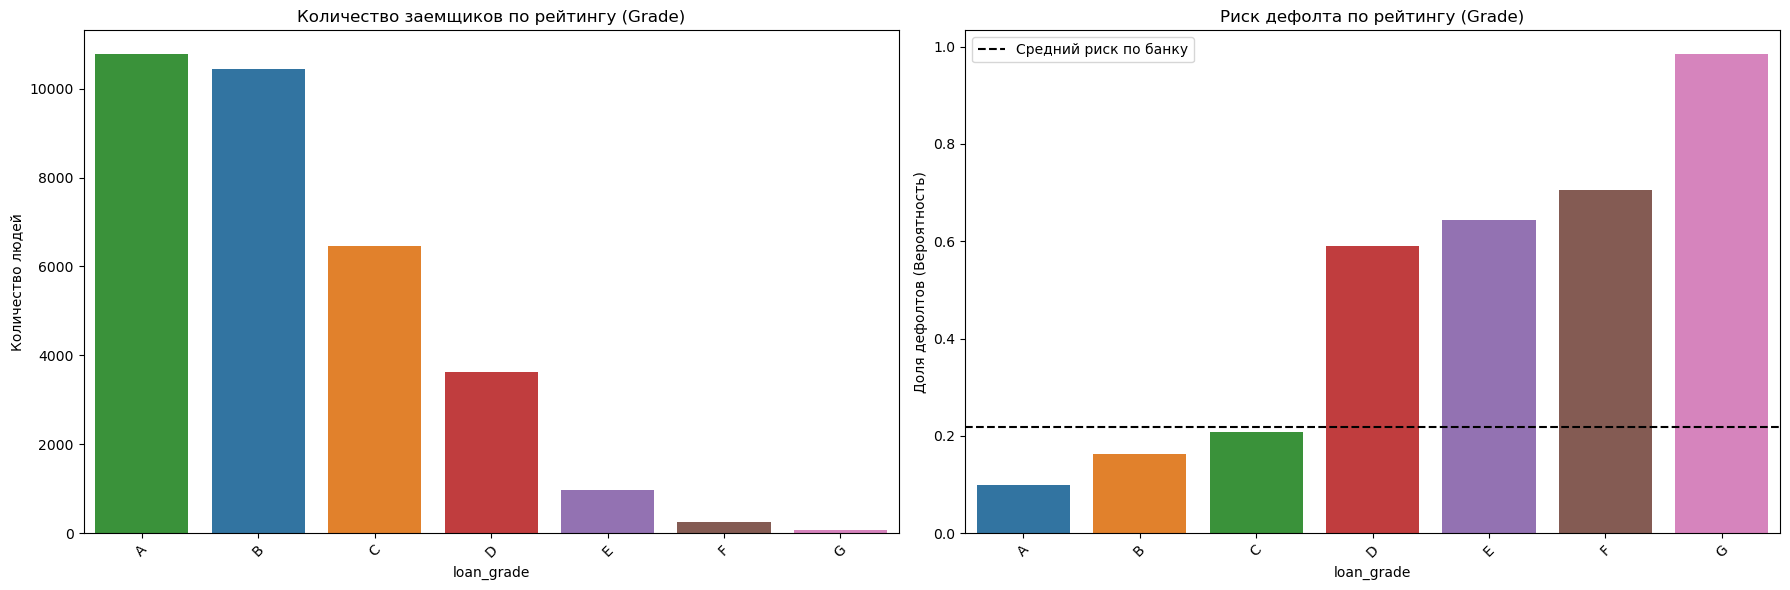

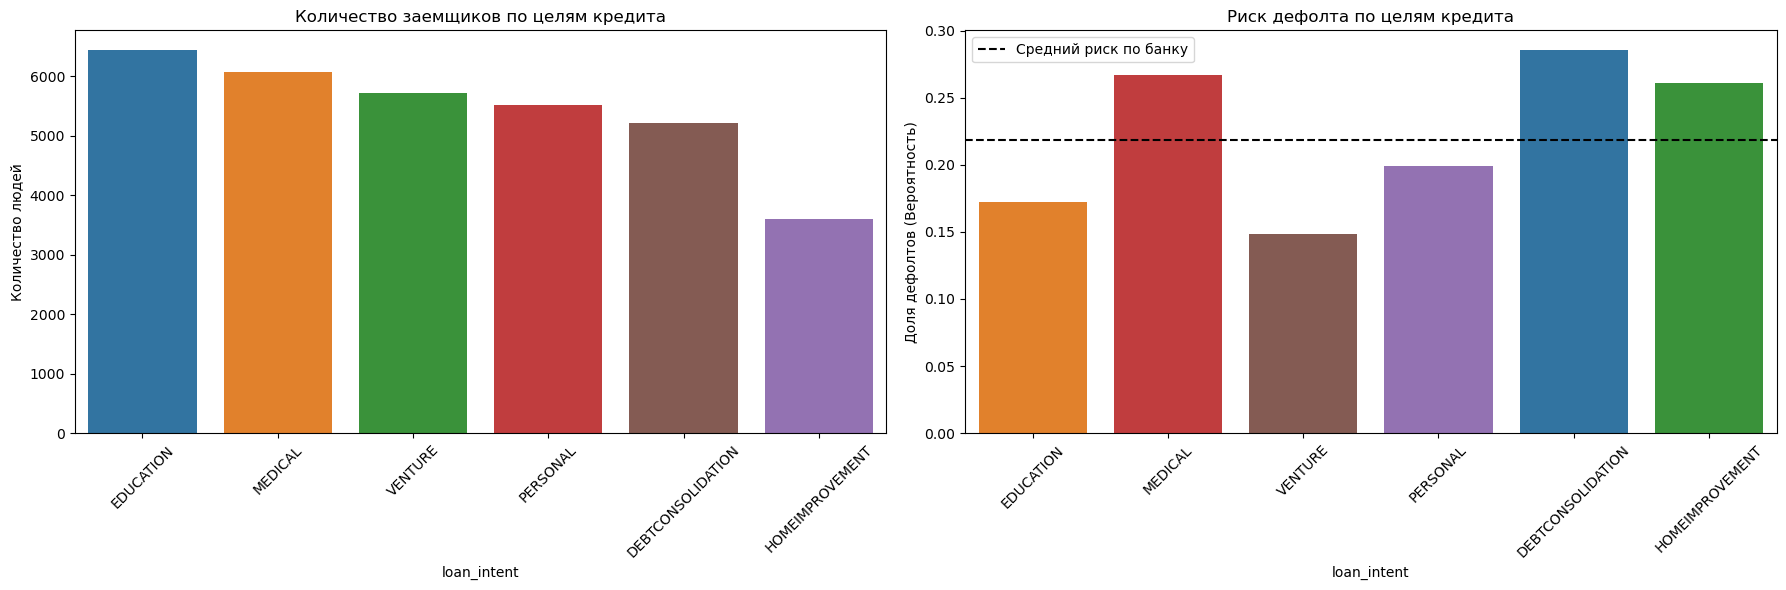

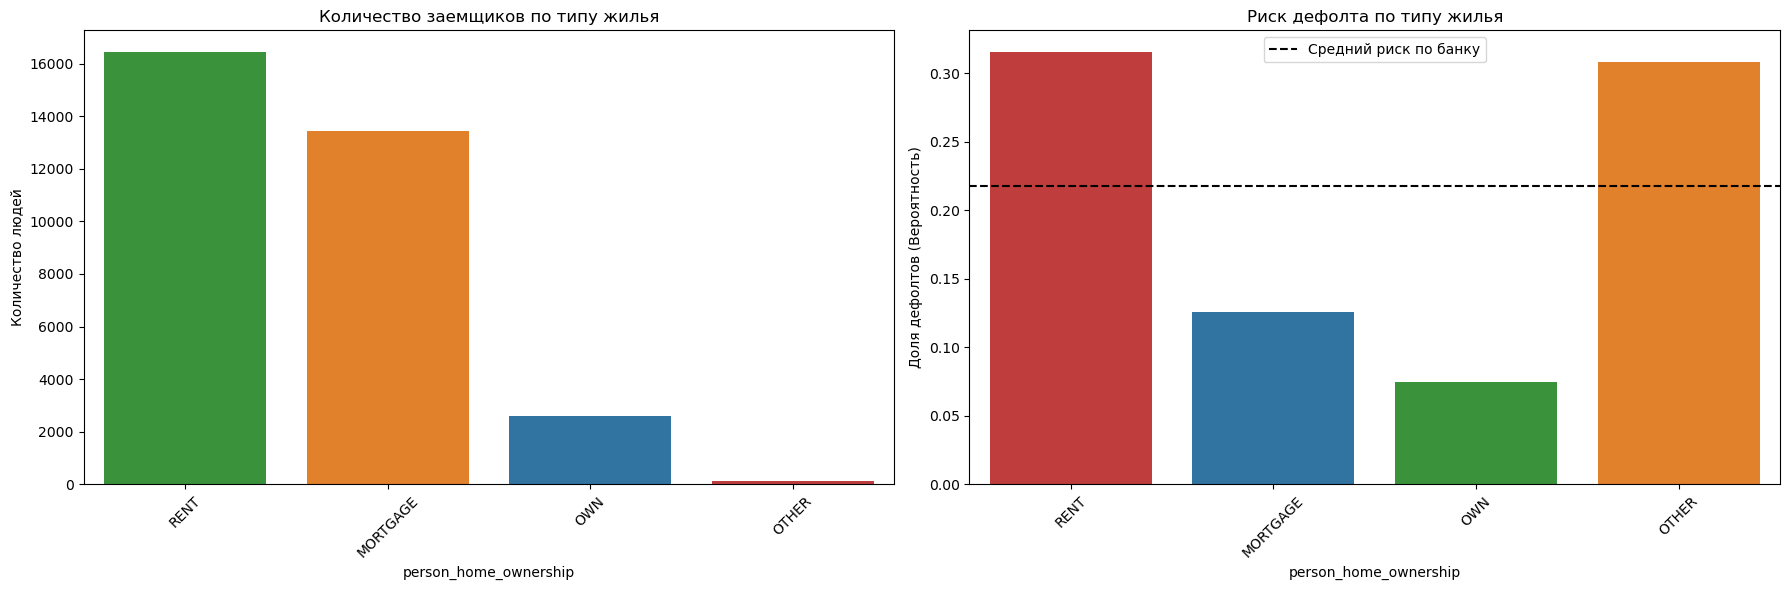

In [251]:
def plot_categorical_analysis(df, column, title_name):
    fig, ax = plt.subplots(1, 2, figsize=(18, 6))
    sns.countplot(x=column, data=df, ax=ax[0], hue=column, order=df[column].value_counts().index)
    ax[0].set_title(f'Количество заемщиков по {title_name}')
    ax[0].set_ylabel('Количество людей')
    ax[0].tick_params(axis='x', rotation=45)
    risk_data = df.groupby(column)['loan_status'].mean().reset_index()
    sns.barplot(x=column, y='loan_status', hue=column, data=risk_data, ax=ax[1], 
                order=df[column].value_counts().index)
    ax[1].set_title(f'Риск дефолта по {title_name}')
    ax[1].set_ylabel('Доля дефолтов (Вероятность)')
    ax[1].tick_params(axis='x', rotation=45)
    ax[1].axhline(df['loan_status'].mean(), color='black', linestyle='--', label='Средний риск по банку')
    ax[1].legend()
    plt.tight_layout()
    plt.show()

plot_categorical_analysis(data_clean, 'loan_grade', 'рейтингу (Grade)')
plot_categorical_analysis(data_clean, 'loan_intent', 'целям кредита')
plot_categorical_analysis(data_clean, 'person_home_ownership', 'типу жилья')

Наблюдения:
> * Самыми "опасными" являются заемщики с самым плохим крдитным рейтингом, но их очень мало. Самое большое значение корреляции будут иметь заемщики с рангом D, так как их ощутимо больше, чем клиентов 'E' 'F' и 'D';
> * Среди целей кредита выделяются 3 категории - медицина, ремонт и покрытие других долгов, чаще всего под такие цели заемщики не возвращали деньги. Это логично, так как ремонт и медицина чаще всего являются внезапными тратами.
> * Вполне возможно что цель DEBTCONSOLIDATION имеет высокое значение корреляции с кредитной историей и кредитным рейтингом (кредиты уже брались и возможно не возвращались).
> * В основном кредиты берут люди со съемным жильем или ипотекой. Причем люди с ипотекой реже не возвращают деньги. Ожидаются большие значения корреляции "аренды" жилья и доходов (а также долей кредита от дохода).

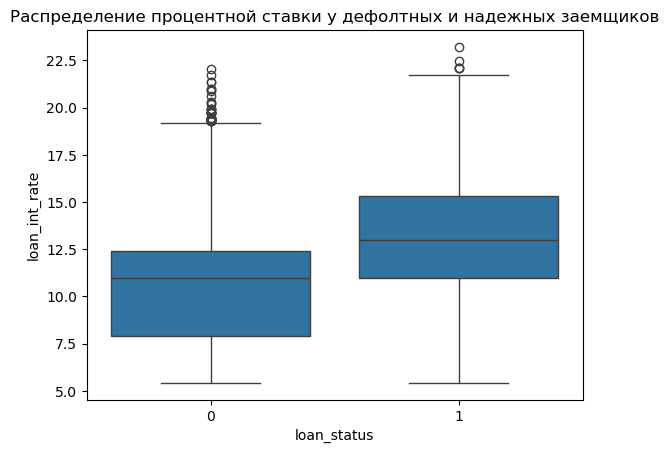

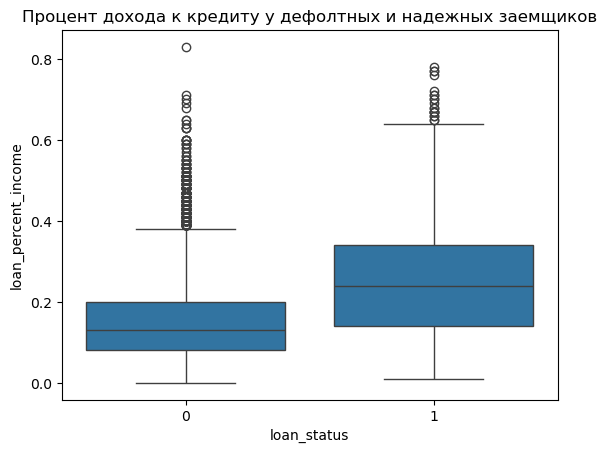

In [271]:
plt.figure()
sns.boxplot(x='loan_status', y='loan_int_rate', data=data_clean)
plt.title('Распределение процентной ставки у дефолтных и надежных заемщиков')
plt.figure()
sns.boxplot(x='loan_status', y='loan_percent_income', data=data_clean)
plt.title('Процент дохода к кредиту у дефолтных и надежных заемщиков')
plt.show()

Было: 13
Стало: 28
------------------------------


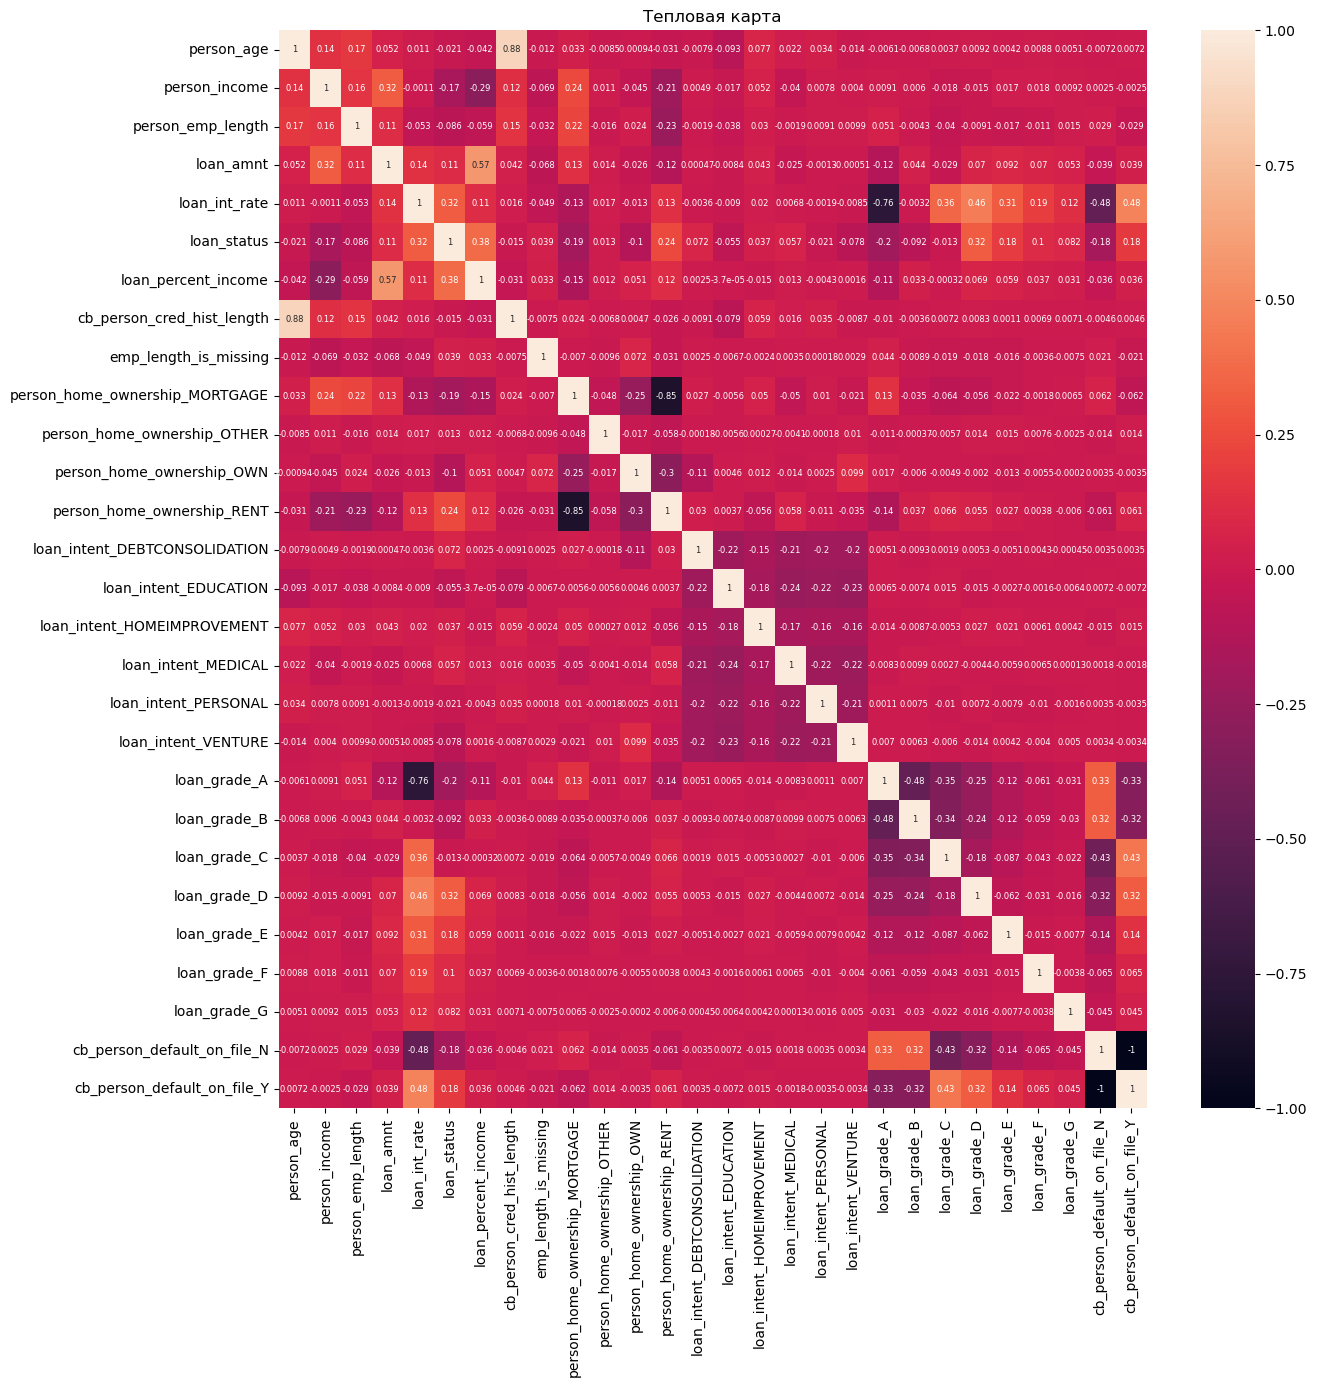

In [273]:
categorical_cols = ['person_home_ownership', 'loan_intent', 'loan_grade', 'cb_person_default_on_file']
data_model_heatmap = pd.get_dummies(data_clean, columns=categorical_cols)
print(f"Было: {data_clean.shape[1]}")
print(f"Стало: {data_model_heatmap.shape[1]}")
print("-" * 30)
plt.figure(figsize=(14, 14))
sns.heatmap(data_model_heatmap.corr(numeric_only=True), annot=True, annot_kws={"size": 6})
plt.title('Тепловая карта')
plt.show()

Карта построена как итог работы с кореляцией, но можно провести дополнительные наблюдения:
> * Людям с рейтингом А дают кредиты под самые низкие проценты, людям с D дают под самые высокие проценты.
> * Больше всего на процент по кредит влияет кредитный рейтинг и опыт невозвращения кредита в прошлом, цель какого-то явного влияния не оказывает;
> * Чаще всего ремонт делают в ипотечном жилье;
> * Чем взрослее человек, тем меньше шансов что он возьмет кредит на обучение - увеличивается вероятность взятия кредита на ремонт;
> * Верный путь к порче кредитного рейтинга - невозврат денег банку в прошлом.

# 2. Предобработка данных
В данной части работы проводится финальная подготовка данных перед обучением. 
* Разбиение на тестовую и обучающую выборки
* Кодировка
* Нормирование

In [226]:
X = data_clean.drop(['loan_status'], axis=1)
Y = data_clean['loan_status']
x_train, x_test, y_train, y_test = train_test_split(X,Y,test_size=0.2,random_state=12)
print(x_train.shape,x_test.shape)
x_train.reset_index(drop=True, inplace = True)
x_test.reset_index(drop=True, inplace = True)

drop_values = ['MORTGAGE', 'EDUCATION', 'A', 'N']
ohe = OneHotEncoder(drop=drop_values, sparse_output=False)
ohe.fit(x_train[categorical_cols])
x_train_en = ohe.transform(x_train[categorical_cols])
x_test_en= ohe.transform(x_test[categorical_cols])
encoded_feature_names = ohe.get_feature_names_out(categorical_cols)
num_cols = x_train.select_dtypes(exclude=['object']).columns
x_train_en = pd.concat([
    x_train[num_cols].reset_index(drop=True),
    pd.DataFrame(x_train_en, columns=encoded_feature_names)
], axis=1)
x_test_en = pd.concat([
    x_test[num_cols].reset_index(drop=True),
    pd.DataFrame(x_test_en, columns=encoded_feature_names)
], axis=1)

(26059, 12) (6515, 12)


In [228]:
num_cols = ['person_age', 'person_income', 'person_emp_length', 'loan_amnt', 'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length']
scaler = StandardScaler()
scaler.fit(x_train_en[num_cols])
x_train_scaled = x_train_en.copy()
x_test_scaled = x_test_en.copy()
x_train_scaled[num_cols] = scaler.transform(x_train_en[num_cols])
x_test_scaled[num_cols] = scaler.transform(x_test_en[num_cols])
x_train_scaled.head()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,emp_length_is_missing,person_home_ownership_OTHER,person_home_ownership_OWN,...,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE,loan_grade_B,loan_grade_C,loan_grade_D,loan_grade_E,loan_grade_F,loan_grade_G,cb_person_default_on_file_Y
0,-0.116519,-0.011093,0.063874,-0.406519,1.886944,-0.565685,0.792639,0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1,-0.277770,-0.297358,1.321997,-0.565181,-0.006120,-0.472017,-0.940839,0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
2,-0.922777,0.179648,-0.187750,0.862774,0.844623,0.277327,-0.445560,0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
3,-0.761525,-0.411650,-0.690999,-0.025731,1.724589,0.370995,-0.693199,0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
4,0.850990,0.656501,-0.942624,2.449391,0.211437,0.745667,0.792639,0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0


> Важное и интересное замечание - кодировщик и нормирователь лучше обучать только на учебной выборке, и уже далее воздействовать ими на тестовые данные. <br>
> Так модель стабильнее будет реагировать на новые данные (и новые категории)

# 3. Обучение моделей, анализ результатов 

В данном проекте рассматриваются три модели, от простого к сложному. 
### Логистическая регрессия
Линейный классификатор аппроксимирующий вероятность принадлежности к классу через логистическую функцию (сигмоиду).
* Обладает высокой интерпретируемостью, коэффициенты явно покажут влияние признака на целевую переменную.
* Низкая вероятность переобучения.
* Модель простая и не способна выявить сложные нелинейные зависимости без дополнительного конструирования признаков (Feature Engineering), требует тщательную предобработку
### Случайный лес (Random Forest)
Ансамблевый алгоритм, основанный на методе бэггинга (Bootstrap Aggregating). Построение итоговой модели происходит путем усреднения прогнозов множества независимых решающих деревьев, обученных на случайных подмножествах данных и признаков.
* Нелинейные связи учитываются без дополнительного создания сложных признаков и предобработки (нормализации)
* Устойчива к переобучению
* Требует больше ресурсов
### CatBoost (Gradient Boosting on Oblivious Trees)
Градиентный бустинг над симметричными решающими деревьями. В отличие от случайного леса, деревья строятся последовательно, где каждое последующее минимизирует функцию потерь (loss function) предыдущей композиции. Российская библиотека.
* Эффективная обработка данных, использование продвинутых схем кодирования, встроенная обработка пропусков
* Сложность интерпретации
* Трудоемкость настройки, эффективность модели сильно зависит от подбора гиперпараметров

In [239]:

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "CatBoost": CatBoostClassifier(iterations=500, verbose=100, random_state=42)
}
comparison = []
for name, model in models.items():
    model.fit(x_train_scaled, y_train)
    y_pred = model.predict(x_test_scaled)
    comparison.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-Score": f1_score(y_test, y_pred)
    })
df_results = pd.DataFrame(comparison).sort_values(by="Recall", ascending=False)
print(df_results)

Learning rate set to 0.078269
0:	learn: 0.6104226	total: 12.2ms	remaining: 6.1s
100:	learn: 0.2035461	total: 422ms	remaining: 1.67s
200:	learn: 0.1812520	total: 786ms	remaining: 1.17s
300:	learn: 0.1678132	total: 1.15s	remaining: 760ms
400:	learn: 0.1563925	total: 1.52s	remaining: 375ms
499:	learn: 0.1466760	total: 1.88s	remaining: 0us
                 Model  Accuracy  Precision    Recall  F1-Score
2             CatBoost  0.941059   0.976077  0.739666  0.841584
1        Random Forest  0.936454   0.970732  0.721537  0.827787
0  Logistic Regression  0.870760   0.761951  0.566352  0.649750


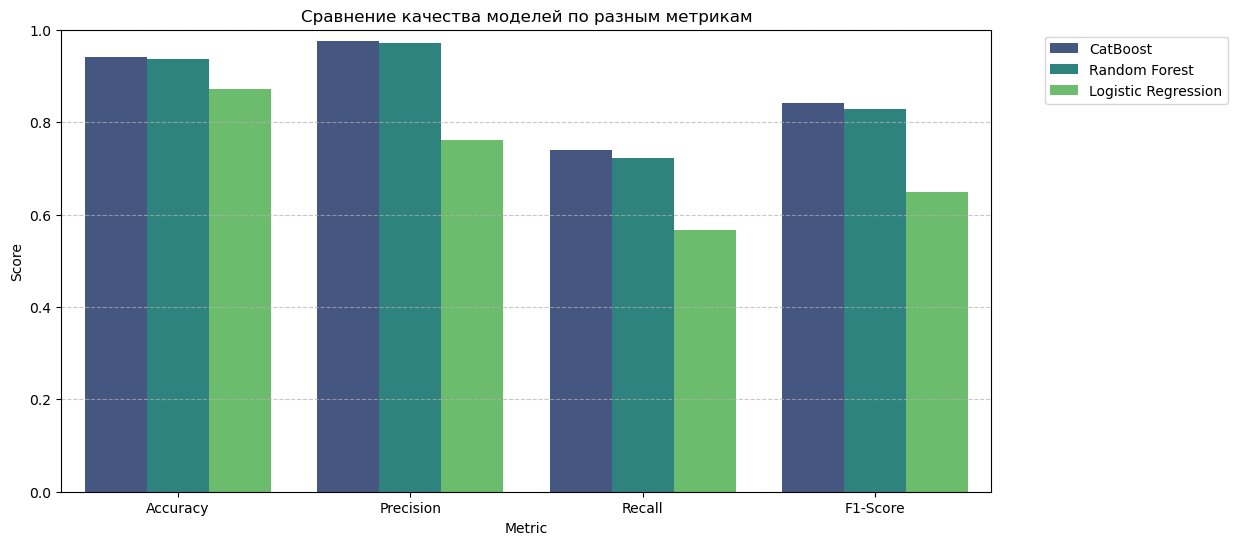

In [245]:

df_melted = df_results.melt(id_vars='Model', var_name='Metric', value_name='Score')
plt.figure(figsize=(12, 6))
sns.barplot(data=df_melted, x='Metric', y='Score', hue='Model', palette='viridis')
plt.title('Сравнение качества моделей по разным метрикам')
plt.ylim(0, 1) # Чтобы шкала была от 0 до 100%
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

> * Для банковских задач выбор метрики играет важную роль.
> * False Positive - влечет за собой отказ в кредите благонадежному заемщику. Упущена выгода в виде процентов которые мог бы заплатить человек.
> * False Negative - пропускает человека, который не вернет выданные ему деньги. У банка будет убыток.
> * Таким образом главной метрикой для рассмотрения будет являться полнота (Recall), но также следует оставлять приемлимый уровень точности (Precision), чтобы банк вообще выдавал кредиты хоть кому-нибудь (ведь можно отказать вообще всем и полнота будет 1)
> * Доля правильных ответов (Accuracy) не актуальна для данной базы данных, так как соотношение классов неравномерное.

<Figure size 800x600 with 0 Axes>

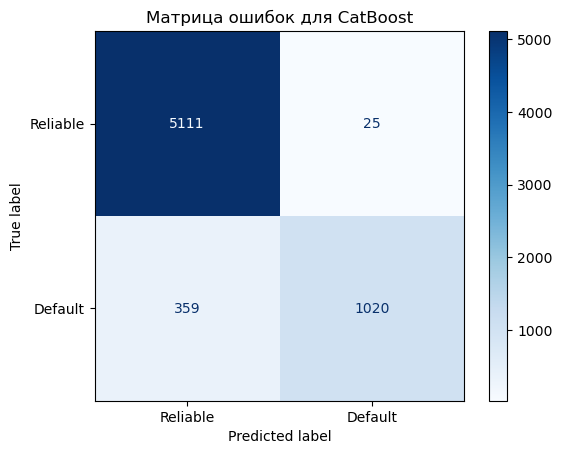

In [281]:
cb_model = models['CatBoost']
cb_pred = cb_model.predict(x_test_scaled)
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
cm = confusion_matrix(y_test, cb_pred)
plt.figure(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Reliable', 'Default'])
disp.plot(cmap='Blues', values_format='d')
plt.title(f'Матрица ошибок для CatBoost')
plt.show()

> * TP: найдено 1020 неблагонадежных клиента
> * FN: пропущено 359 клиентов, которые не вернут кредит (главная зона риска)
> * TN: найдено 5111 новых клиента которым безопасно выдавать кредиты
> * FP: пропущено 25 бедолаг, которые и рады бы вернуть кредит, но им его не дали (упущенная выгода)

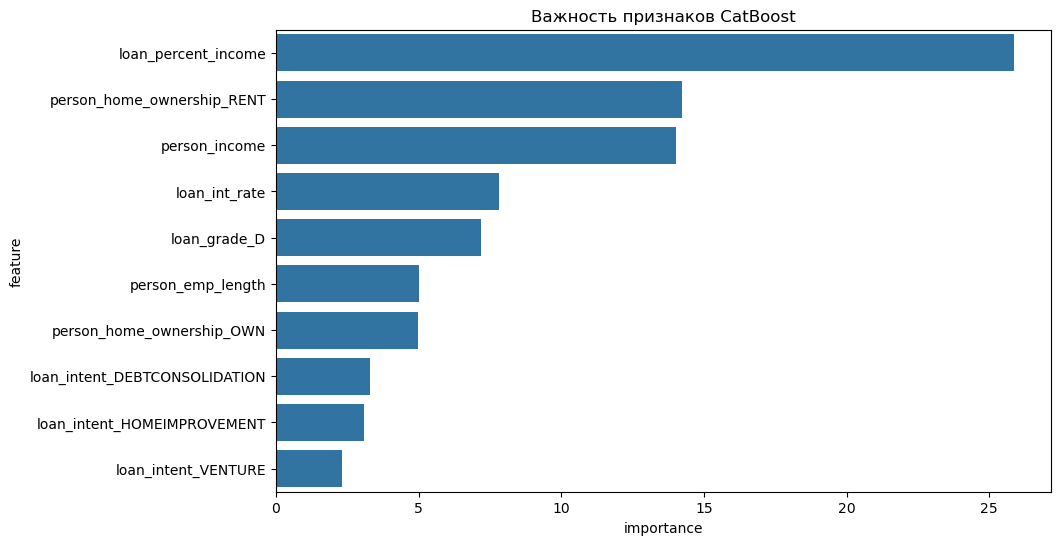

In [289]:
feature_importance = cb_model.get_feature_importance()
feature_names = x_train_scaled.columns
fi_df = pd.DataFrame({'feature': feature_names, 'importance': feature_importance})
fi_df = fi_df.sort_values(by='importance', ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x='importance', y='feature', data=fi_df)
plt.title('Важность признаков CatBoost')
plt.show()

Наблюдения:
> * Результаты анализа важности признаков согласуются с корреляционным анализом, который был проведен ранее.
> * Применение градиентного бустинга позволило учесть нелинейные зависимости, что обеспечило более высокий Recall чем в линейной модели, которая тесно связана со значениями корреляции. 


# Заключение и выводы

### Анализ данных и ключевые наблюдения (EDA)
В ходе исследовательского анализа было подтверждено, что данные обладают высокой предсказательной способностью. Основными детерминантами дефолта являются:
* Долговая нагрузка (loan_percent_income): Установлена сильная положительная корреляция с риском невозврата. Заемщики, чьи выплаты превышают 30% от дохода, попадают в зону критического риска.
* Кредитная история (cb_person_default_on_file): Наличие факта дефолта в прошлом является наиболее стабильным предиктором будущего нарушения обязательств, а также причиной плохого рейтинга.
* Процентная ставка (loan_int_rate): Выявлена прямая зависимость — высокие ставки коррелируют с повышенным риском невозврата кредита.
### Результаты моделирования
В рамках работы было проведено обучение и сравнение трех архитектур: Logistic Regression, Random Forest и CatBoost. 
* CatBoost Classifier ожидаемо продемонстрировал наилучшие результаты, достигнув Accuracy ~94% и Recall ~74%.
* При более серьезном подходе к настройке моделей и исходных данных можно добиться улучшения метрик и на остальных моделях. Рассмотренная база данных небольшая и несложная, поэтому не возникло проблем с нехваткой мощностей для более продвинутой модели и проблем с интерпретируемостью результатов.
### Направления для дальнейшего развития проекта:
* Рассмотреть большее колличество моделей для сравнения, провести исследование и настроку гиперпараметров для улучшения результатов.
* Более углубленная предобработка.
* Проведение анализа интерпретируемости. 